In [9]:
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt
from collections import Counter

iris = datasets.load_iris()
iris_data = iris.data # separate training variables
iris_labels = iris.target #what we are predicting

In [10]:
np.random.seed(42) # The random seed is set to 42 to ensure that any random operations will produce the same result each time
# the code is run

#randomized permutatuion of the len(iris_data)=150
#array of size 150

indices = np.random.permutation(len(iris_data))

#Set test sample to 45 for a 70/30 split of the data.

n_test_samples = 12

#This splits the iris data set into training and testing sets based on the n_test_samples.
trainset_data = iris_data[indices[:-n_test_samples]]
trainset_labels = iris_labels[indices[:-n_test_samples]]
testset_data = iris_data[indices[-n_test_samples:]]
testset_labels = iris_labels[indices[-n_test_samples:]]

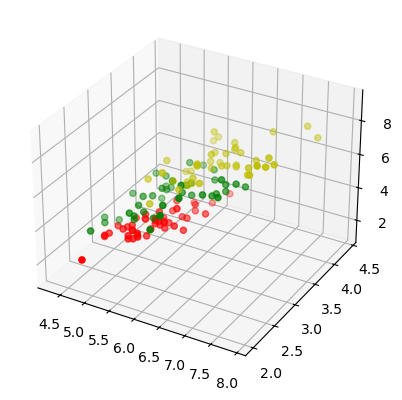

In [11]:
X = [] #Initialize an empty where it stores data for the 3 Iris classes.

#create list for the three classes of Iris (red, green, yellow)
for iclass in range(3):
    X.append([[], [], []]) # Adds 3 empty sublist for each class

    #categorize the three different species to visualize them. We are summing over the last two attributes for the purpose
    #iclass = contains the three different iris classes
    for i in range(len(trainset_data)):
        if trainset_labels[i] == iclass:
            X[iclass][0].append(trainset_data[i][0]) #Stores the 1st feautre
            X[iclass][1].append(trainset_data[i][1]) #Stores the second feature
            X[iclass][2].append(sum(trainset_data[i][2:])) # Stores the sum of the remaining features as the third dimension

# The colors represent the species
#We can see that we have three separate clusters and, partially, how they differentiate from each other

colors = ("r","g","y") # Defines the red, green, and yellow for the 3 species


fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')
#It creates a figure where it is a 3D subplot

#create scatter plot
for iclass in range(3): # This creates the subplot for each class using their respective colors
    ax.scatter(X[iclass][0], X[iclass][1], X[iclass][2], c=colors[iclass])
plt.show() # Displays the plot

#he colors represent the species 
#we can see that we have three separate clusters and partially how they differentiate from each other



In [12]:
#calculate the distance between two arrays using Numpy Package

def distance(instance1, instance2):
    """
    
    Gets the Euclidean distance between the two instances of data

    The function would first convert both of the instances to NumPy 
    arrays. After that, it could calculate and return the Euclidean
    distance by subtracting instance2 from instance1 to get the difference vector

    Parameters
    ---------------
    instance1 : array-like
        First input array or list
    instance2 : array-like
        Second input array or list

    Returns
    -----------------
    float
        The Euclidean distance between two input arrays

    Notes
    --------------
    Both inputs are converted to NumPy arrays before calculation.
    The np.linalg.norm computes the L2 Norm of the element-wise difference.
    

    """
    

    instance1 = np.array(instance1)
    instance2 = np.array(instance2)

    return np.linalg.norm(instance1 - instance2)

In [13]:
#build b=nearest neighbor model defining training set,dependent variable, our test data, value of k (number of voters) as well as

def get_neighbors(training_set, labels,test_instance, k, distance=distance):
    #the loop will calculate distance between points to be classified correctly
    #plot above shows actual points. Here we model and predict what these points would be, especially when using unseen data
    """
    Finds the k-nearest neighbors for a given test instance using KNN algorithm

    This function first creates an empty list, distance, where
    it stores information about the training point, the distance to that point, and its type
    for the test_instance. The function would go through all of the training data set
    to get the distance of each data point for the test_instance, once done,
    the .sort would sort all distances in ascending order from least to greatest based on the distance value.
    The neighbor variable would select items up to value k in the distance to return
    the nearest data points to the test_instance up to k.

    Parameters
    -----------------
    training_set : array-like
        The training dataset contains feature vectors for each training example.
    
    labels : array-like
        The corresponding labels/species for each training example.

    test_instance : array-like
        The test point for which to find the nearest neighbors.

    k : int 
        The number of nearest neighbors to return.
    distance : function
        Distance function to calculate the similarity between points.
        
    Returns
    --------
    neighbors
        A list containing the k nearest neighbors, where each tuple contains:
        (training point, distance_to_test_point, label)

    Example:
    >>> neighbors = get_neighbors(X_train, y_train, test_point, k=3,distance=distance)
    >>> print(neighbors)
    [(training_point1,0.5, 'labelA),training_point2,0.8, 'labelB),....]
        

    """

    distances = []

    for index in range(len(training_set)):
        dist = distance(test_instance,training_set[index])
        distances.append((training_set[index],dist,labels[index]))
    distances.sort(key=lambda x: x[1])
    neighbors = distances[:k]
    return(neighbors)

In [14]:
#define vote that will look at distance that are the closest points to each point voted on.
#vote whether it is 0,1, or 2.

def vote(neighbors):
    """
    Determines the class label/species that is most common in the neighbor list

    The functions basically implement a voting mechanism that is usually used in k-nearest neighbor
    classification. It counts the occurrences of each class label/species among the neighbors
    and returns the class/ species that appeared the most.

    Parameters:
    neighbors: iterable list tuple
        A collection of neighbor data points where each neighbor is expected
        to have a class label/species at index 2 (neighbor[2]).
    Returns:
    ------------
    class label/species
        The class label/species that appears most frequently among neighbors.
    >>> Example:
    --------
    >>> neighbors = [(1, 2, 0), (3, 4, 1), (5, 6, 0), (7, 8, 0)]
    >>> print(vote(neighbors))
    0
    
    """
    class_counter = Counter()
    for neighbor in neighbors:
        class_counter[neighbor[2]] += 1
    return class_counter.most_common(1)[0][0]

In [15]:
#show and print results

for i in range(n_test_samples): 
    #Up to the test samples, run the KNN classifier
    #on each test sample and displays both the prediction and the truth
    # for comparison to see if KNN predicted it correctly
    
    neighbors = get_neighbors(trainset_data,
                           trainset_labels,
                           testset_data[i],
                           3,
                           distance=distance)
    print("index: ", i,
          ", result of vote: ", vote(neighbors), # get the predicted class label/species of Iris flower
          ", label: ", testset_labels[i], #The actual class label/species of the Iris flower
          ", data: ", testset_data[i]) # The actual data values of the test sample
    

index:  0 , result of vote:  1 , label:  1 , data:  [5.7 2.8 4.1 1.3]
index:  1 , result of vote:  2 , label:  2 , data:  [6.5 3.  5.5 1.8]
index:  2 , result of vote:  1 , label:  1 , data:  [6.3 2.3 4.4 1.3]
index:  3 , result of vote:  1 , label:  1 , data:  [6.4 2.9 4.3 1.3]
index:  4 , result of vote:  2 , label:  2 , data:  [5.6 2.8 4.9 2. ]
index:  5 , result of vote:  2 , label:  2 , data:  [5.9 3.  5.1 1.8]
index:  6 , result of vote:  0 , label:  0 , data:  [5.4 3.4 1.7 0.2]
index:  7 , result of vote:  1 , label:  1 , data:  [6.1 2.8 4.  1.3]
index:  8 , result of vote:  1 , label:  2 , data:  [4.9 2.5 4.5 1.7]
index:  9 , result of vote:  0 , label:  0 , data:  [5.8 4.  1.2 0.2]
index:  10 , result of vote:  1 , label:  1 , data:  [5.8 2.6 4.  1.2]
index:  11 , result of vote:  2 , label:  2 , data:  [7.1 3.  5.9 2.1]
